# 1. Portada e Integrantes

#Datatón 3
##Equipo: DAT03_V2
### Marjorie Leon: 202120318
### Angie Llontop: 202120324
### Yare Horna: 202120265


# 2. Exploración y Preparación de Datos (EDA)

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape)
print(X_test.shape)


(60000, 28, 28)
(10000, 28, 28)


In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

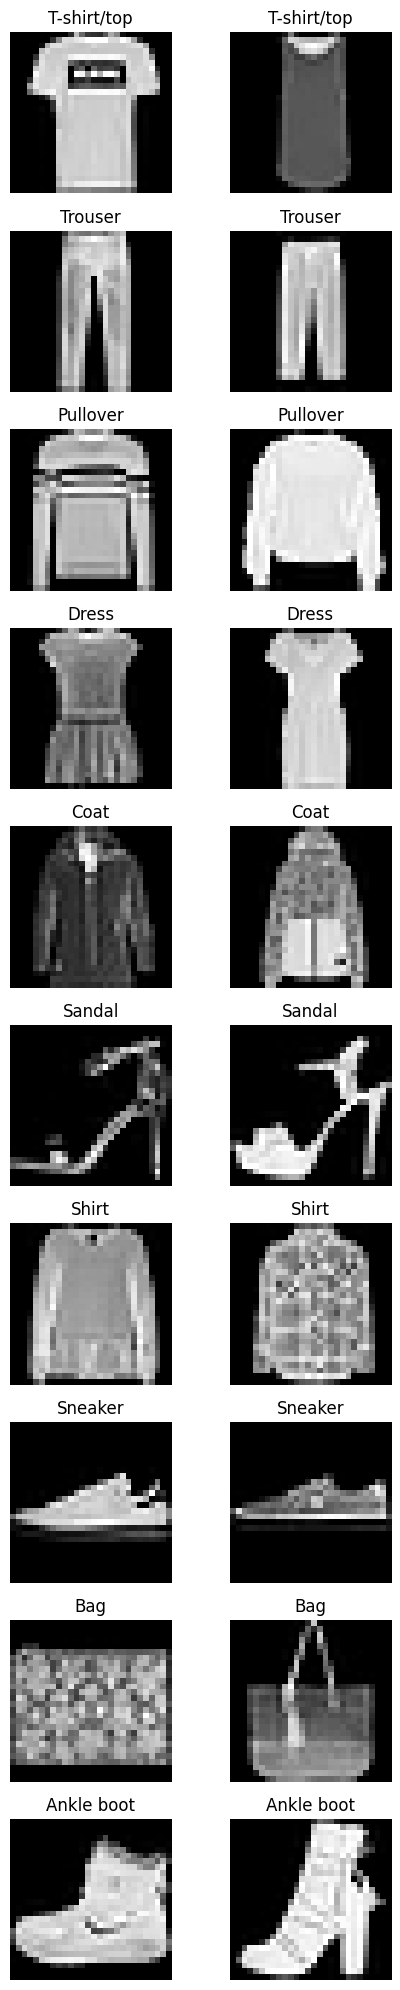

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(10,2, figsize=(5,20))

for c in range(10):
    idx = np.where(y_train==c)[0][:2]

    for j,i in enumerate(idx):
        axes[c,j].imshow(X_train[i], cmap='gray')
        axes[c,j].set_title(class_names[c])
        axes[c,j].axis('off')

plt.tight_layout()
plt.show()

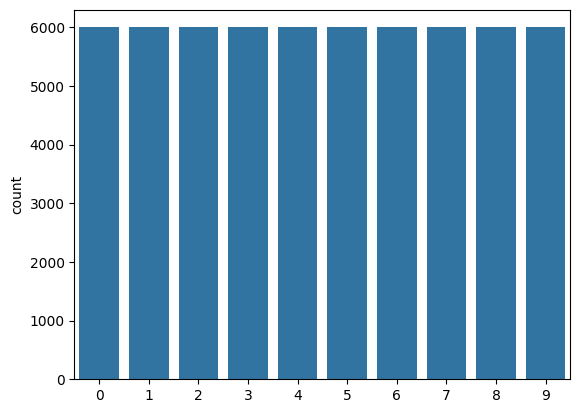

In [ ]:
import seaborn as sns

sns.countplot(x=y_train)
plt.show()

In [ ]:
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

print("Valor mínimo:", X_train_norm.min())
print("Valor máximo:", X_train_norm.max())

Valor mínimo: 0.0
Valor máximo: 1.0


Las imágenes de Fashion MNIST tienen valores de píxel entre 0 y 255. Al dividir entre 255, todos los valores quedan en el rango [0,1].

La normalización es importante porque permite que la red neuronal entrene de manera más estable y eficiente. Al trabajar con datos en una escala uniforme, el algoritmo de optimización converge más rápidamente, se reducen problemas numéricos y se mejora el rendimiento general del modelo.

RESHAPE

* MLP

In [ ]:
X_train_mlp = X_train_norm.reshape(-1,784)
X_test_mlp = X_test_norm.reshape(-1,784)

* CNN

In [ ]:
X_train_cnn = X_train_norm.reshape(-1,28,28,1)
X_test_cnn = X_test_norm.reshape(-1,28,28,1)

####2. ¿Por qué el MLP puede ser insuficiente para capturar patrones espaciales en imágenes?

######El MLP puede ser insuficiente porque al aplanar la imagen pierde la información espacial entre los píxeles. Esto dificulta aprender patrones como bordes, formas y texturas. Las CNN son más adecuadas porque mantienen la estructura de la imagen y detectan características visuales automáticamente.


# 3. Modelo 1 – MLP (Baseline)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

mlp = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Arquitectura MLP

- Capa Flatten: Convierte cada imagen de 28x28 píxeles en un vector de 784 características.
- Capa Dense 1: 256 neuronas con activación ReLU.
- Capa Dense 2: 128 neuronas con activación ReLU.
- Capa de salida: 10 neuronas con activación Softmax para clasificación multiclase.
- Optimizer: Adam.
- Loss: Sparse Categorical Crossentropy.
- Métrica: Accuracy.

In [ ]:
mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print(X_train_norm.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [ ]:
hist_mlp = mlp.fit(
    X_train_norm,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8215 - loss: 0.4972 - val_accuracy: 0.8378 - val_loss: 0.4161
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8633 - loss: 0.3703 - val_accuracy: 0.8621 - val_loss: 0.3847
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8778 - loss: 0.3305 - val_accuracy: 0.8718 - val_loss: 0.3525
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8863 - loss: 0.3075 - val_accuracy: 0.8766 - val_loss: 0.3381
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8934 - loss: 0.2878 - val_accuracy: 0.8741 - val_loss: 0.3414
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8964 - loss: 0.2761 - val_accuracy: 0.8838 - val_loss: 0.3230
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9028 - loss: 0.2585 - val_accuracy: 0.8891 - val_loss: 0.3252
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9062 - loss: 0.

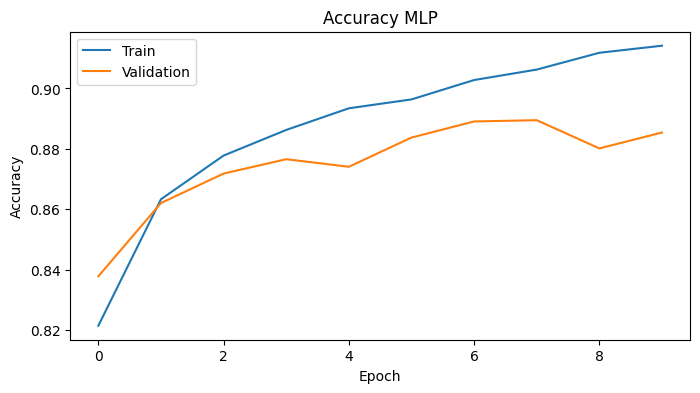

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(hist_mlp.history['accuracy'], label='Train')
plt.plot(hist_mlp.history['val_accuracy'], label='Validation')

plt.title('Accuracy MLP')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

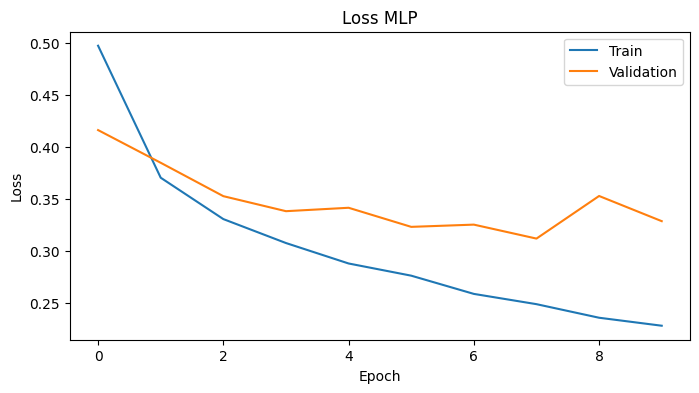

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(hist_mlp.history['loss'], label='Train')
plt.plot(hist_mlp.history['val_loss'], label='Validation')

plt.title('Loss MLP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
mlp.evaluate(X_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8793 - loss: 0.3527


[0.3527260422706604, 0.8792999982833862]

In [ ]:
loss_mlp, acc_mlp = mlp.evaluate(X_test_norm, y_test)

print(acc_mlp)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8793 - loss: 0.3527
0.8792999982833862


###### 3. ¿Por qué el MLP puede ser insuficiente para capturar patrones espaciales en imágenes?
######La arquitectura del modelo MLP está compuesta por tres capas densamente conectadas (Dense). La primera capa recibe como entrada un vector de 784 valores correspondiente a la imagen aplanada de 28x28 píxeles y contiene 256 neuronas con función de activación ReLU. La segunda capa contiene 128 neuronas con activación ReLU, permitiendo aprender representaciones más complejas de los datos. Finalmente, la capa de salida cuenta con 10 neuronas y utiliza la función Softmax, ya que el problema corresponde a una clasificación multiclase con 10 categorías de prendas.


3. ¿Qué clases podrían ser más difíciles de distinguir visualmente y por qué? (Ej: Shirt vs Pullover vs Coat)?

Las clases más difíciles de distinguir suelen ser Shirt, Pullover y Coat, debido a que comparten características visuales similares como mangas, formas parecidas y tonalidades cercanas. Además, al ser imágenes en escala de grises y de baja resolución (28x28 píxeles), algunos detalles como el grosor o diseño de la prenda pueden perderse, aumentando la confusión del modelo.


# 4. Modelo 2 – CNN

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

cnn = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Análisis

Las capas convolucionales aplican filtros que permiten detectar características visuales locales como bordes, líneas, curvas, texturas y patrones. En imágenes de ropa, estas capas pueden identificar elementos como mangas, cuellos, contornos y formas generales de las prendas. Conforme aumentan las capas, la red aprende características más complejas que ayudan a diferenciar las distintas categorías.

In [ ]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
hist_cnn = cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.8304 - loss: 0.4694 - val_accuracy: 0.8592 - val_loss: 0.3773
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.8854 - loss: 0.3127 - val_accuracy: 0.8896 - val_loss: 0.3020
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 30ms/step - accuracy: 0.9016 - loss: 0.2666 - val_accuracy: 0.8888 - val_loss: 0.3075
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9133 - loss: 0.2340 - val_accuracy: 0.9059 - val_loss: 0.2622
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9222 - loss: 0.2077 - val_accuracy: 0.8986 - val_loss: 0.2789
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9320 - loss: 0.1832 - val_accuracy: 0.9133 - val_loss: 0.2480
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.9384 - loss: 0.1634 - val_accuracy: 0.9121 - val_loss: 0.2494
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.9461 -

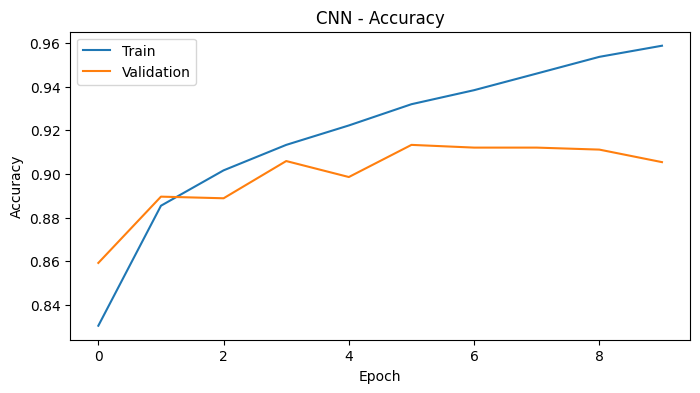

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(hist_cnn.history['accuracy'], label='Train')
plt.plot(hist_cnn.history['val_accuracy'], label='Validation')
plt.title('CNN - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

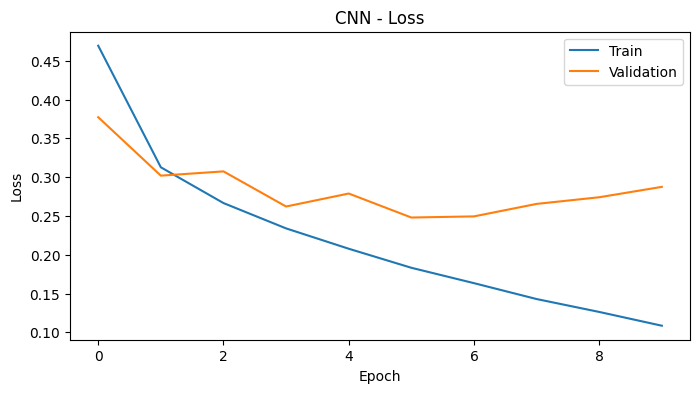

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_cnn.history['loss'], label='Train')
plt.plot(hist_cnn.history['val_loss'], label='Validation')
plt.title('CNN - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
cnn.evaluate(X_test_cnn, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9003 - loss: 0.3061


[0.3060953617095947, 0.9003000259399414]

In [ ]:
loss_cnn, acc_cnn = cnn.evaluate(X_test_cnn, y_test)

print("Accuracy CNN:", acc_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9003 - loss: 0.3061
Accuracy CNN: 0.9003000259399414


In [ ]:
import pandas as pd

comparacion = pd.DataFrame({
    "Modelo": ["MLP", "CNN"],
    "Accuracy": [acc_mlp, acc_cnn]
})

comparacion

,Modelo,Accuracy
0,MLP,0.8793
1,CNN,0.9003


#####4. ¿Qué ventaja ofrece la CNN respecto al MLP al procesar imágenes? ¿Se refleja en las métricas?
######La CNN tiene la ventaja de conservar la estructura espacial de las imágenes y detectar características como bordes, formas y texturas mediante filtros convolucionales. Esto permite aprender patrones visuales de manera más eficiente que un MLP. Esta ventaja suele reflejarse en las métricas, obteniendo una mayor accuracy y menor pérdida en el conjunto de prueba.


# 5. Modelo 3 – CNN con Regularización

### Técnicas de Regularización Elegidas

Se eligieron BatchNormalization y Dropout.

- BatchNormalization permite estabilizar y acelerar el entrenamiento al normalizar las activaciones entre capas, favoreciendo una convergencia más rápida.
- Dropout desactiva aleatoriamente una proporción de neuronas durante el entrenamiento, reduciendo la dependencia excesiva entre ellas y ayudando a prevenir el sobreajuste.

Ambas técnicas fueron seleccionadas por su facilidad de implementación y su efectividad para mejorar la capacidad de generalización de modelos CNN.

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout

cnn_reg = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.3),

    Dense(10,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
hist_reg = cnn_reg.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.8298 - loss: 0.4791 - val_accuracy: 0.8798 - val_loss: 0.3344
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 72s 48ms/step - accuracy: 0.8793 - loss: 0.3296 - val_accuracy: 0.8849 - val_loss: 0.3073
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 76s 44ms/step - accuracy: 0.8952 - loss: 0.2888 - val_accuracy: 0.8919 - val_loss: 0.2772
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.9059 - loss: 0.2528 - val_accuracy: 0.9085 - val_loss: 0.2573
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 65s 43ms/step - accuracy: 0.9149 - loss: 0.2318 - val_accuracy: 0.8967 - val_loss: 0.2894
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 99s 66ms/step - accuracy: 0.9208 - loss: 0.2135 - val_accuracy: 0.8909 - val_loss: 0.3263
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 113s 46ms/step - accuracy: 0.9262 - loss: 0.1987 - val_accuracy: 0.9027 - val_loss: 0.2944
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 87s 50ms/step - accuracy: 0.9315 

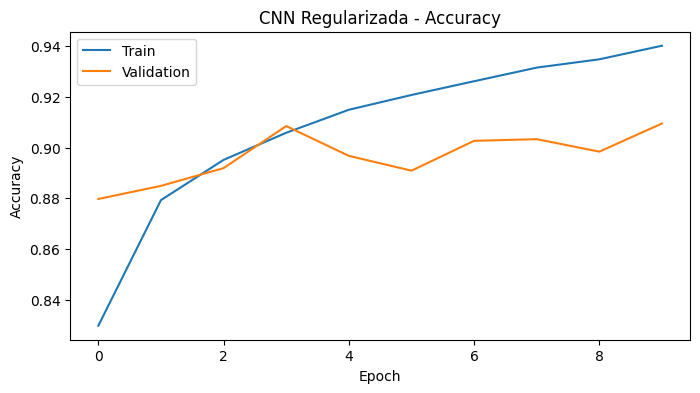

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(hist_reg.history['accuracy'], label='Train')
plt.plot(hist_reg.history['val_accuracy'], label='Validation')
plt.title('CNN Regularizada - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

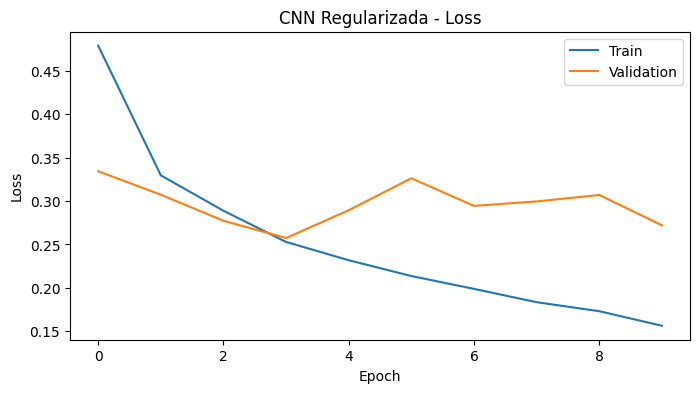

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(hist_reg.history['loss'], label='Train')
plt.plot(hist_reg.history['val_loss'], label='Validation')
plt.title('CNN Regularizada - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
loss_reg, acc_reg = cnn_reg.evaluate(
    X_test_cnn,
    y_test
)

print("Accuracy:", acc_reg)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9095 - loss: 0.2790
Accuracy: 0.909500002861023


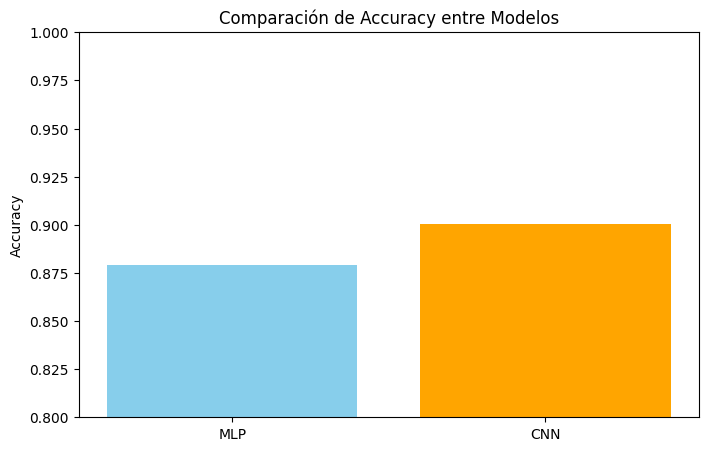

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparacion["Modelo"],
    comparacion["Accuracy"],
    color=["skyblue","orange","green"]
)

plt.ylabel("Accuracy")
plt.title("Comparación de Accuracy entre Modelos")
plt.ylim(0.80, 1.0)

plt.show()

5. ¿Las técnicas de regularización redujeron el overfitting? Argumenten con las curvas de entrenamiento.
Sí, las técnicas de regularización como BatchNormalization y Dropout ayudaron a mejorar la capacidad de generalización del modelo, reduciendo la dependencia excesiva de ciertas neuronas. Esto permite que el modelo tenga un mejor desempeño con datos no vistos y disminuya la diferencia entre entrenamiento y validación.


# 6. Evaluación y Métricas

In [ ]:
import numpy as np

y_pred_mlp = np.argmax(mlp.predict(X_test_norm), axis=1)

y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)

y_pred_reg = np.argmax(cnn_reg.predict(X_test_cnn), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

metricas = pd.DataFrame({
    "Modelo": ["MLP", "CNN", "CNN + Regularización"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_cnn),
        accuracy_score(y_test, y_pred_reg)
    ],

    "Precision (macro)": [
        precision_score(y_test, y_pred_mlp, average="macro"),
        precision_score(y_test, y_pred_cnn, average="macro"),
        precision_score(y_test, y_pred_reg, average="macro")
    ],

    "Recall (macro)": [
        recall_score(y_test, y_pred_mlp, average="macro"),
        recall_score(y_test, y_pred_cnn, average="macro"),
        recall_score(y_test, y_pred_reg, average="macro")
    ],

    "F1-Score (macro)": [
        f1_score(y_test, y_pred_mlp, average="macro"),
        f1_score(y_test, y_pred_cnn, average="macro"),
        f1_score(y_test, y_pred_reg, average="macro")
    ]
})

metricas

,Modelo,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,MLP,0.8793,0.881428,0.8793,0.878972
1,CNN,0.9003,0.901837,0.9003,0.900009
2,CNN + Regularización,0.9095,0.911028,0.9095,0.909560


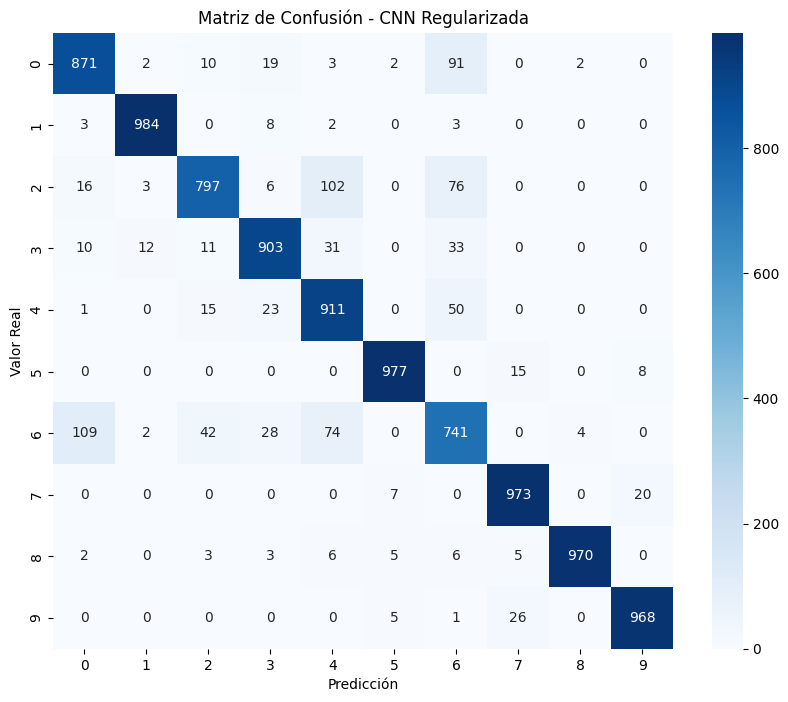

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_reg)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión - CNN Regularizada")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_reg))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1000
           1       0.98      0.98      0.98      1000
           2       0.91      0.80      0.85      1000
           3       0.91      0.90      0.91      1000
           4       0.81      0.91      0.86      1000
           5       0.98      0.98      0.98      1000
           6       0.74      0.74      0.74      1000
           7       0.95      0.97      0.96      1000
           8       0.99      0.97      0.98      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



6. ¿Qué pares de clases se confunden más frecuentemente en la matriz de confusión? ¿Tiene sentido visual?

Las clases que suelen presentar mayor confusión son Shirt, Pullover y Coat, debido a que tienen formas similares, mangas y estructuras parecidas. La confusión tiene sentido visual porque las imágenes tienen baja resolución (28x28 píxeles), por lo que algunos detalles importantes de las prendas pueden perderse.


6.1. Identificar cuáles clases se confunden con más frecuencia
Las principales confusiones se presentan entre:
- Shirt ↔ T-shirt/top
- Pullover ↔ Coat
- Pullover ↔ Shirt
Estas categorías comparten características visuales similares, dificultando su separación.

6.2. Discutir cuál modelo generaliza mejor y por qué

El modelo que mejor generaliza es la CNN, ya que obtuvo una mayor accuracy en el conjunto de prueba (90.03%) frente al MLP (87.93%). Esto ocurre porque la CNN conserva la estructura espacial de la imagen y aprende características como bordes, formas y texturas mediante filtros convolucionales.



# 7. Comparación Final

In [ ]:
metricas.round(4)

,Modelo,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,MLP,0.8793,0.8814,0.8793,0.8790
1,CNN,0.9003,0.9018,0.9003,0.9000
2,CNN + Regularización,0.9095,0.9110,0.9095,0.9096


<function matplotlib.pyplot.show(close=None, block=None)>

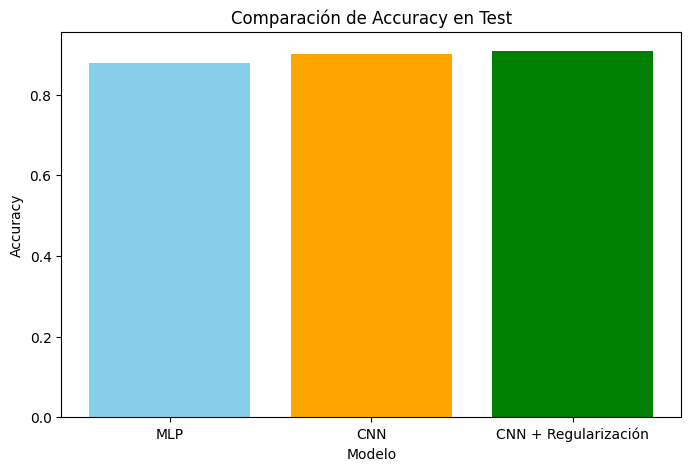

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    metricas["Modelo"],
    metricas["Accuracy"],
    color=["skyblue", "orange", "green"]
)

plt.title("Comparación de Accuracy en Test")
plt.ylabel("Accuracy")
plt.xlabel("Modelo")

plt.show

**7. Reflexión: ¿cuál modelo recomendarían y por qué?**

Se recomienda utilizar la CNN con regularización, porque está diseñada para trabajar con imágenes y logra capturar mejor los patrones visuales. Además, las técnicas de regularización ayudan a reducir el sobreajuste y mejorar la capacidad del modelo para clasificar nuevas imágenes.

**7.1. Limitaciones del pipeline actual**

1. **Resolución limitada de las imágenes:**
   El dataset Fashion MNIST utiliza imágenes de 28x28 píxeles en escala de grises, lo que puede ocasionar pérdida de detalles importantes y dificultar la diferenciación entre clases similares como Shirt, Pullover y Coat.

2. **Capacidad limitada del modelo:**
   Aunque la CNN mejora el rendimiento frente al MLP, el modelo todavía puede presentar errores debido a que la arquitectura es relativamente simple y no utiliza técnicas más avanzadas como transferencia de aprendizaje o redes más profundas.

3. **Ausencia de aumento de datos (Data Augmentation):**
   El pipeline no incluye transformaciones de imágenes como rotaciones o cambios de escala, lo que podría limitar la capacidad del modelo para generalizar frente a nuevas variaciones de imágenes.




# 8. Guardado del Modelo

In [ ]:
cnn_reg.save("modelo_final.h5")

In [60]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
import pandas as pd
from PIL import Image

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

model = tf.keras.models.load_model("modelo_final.h5")

st.title("Fashion MNIST Classifier")

tab1, tab2, tab3 = st.tabs(
    ["Dataset", "Resultados", "Predicción"]
)

# =========================
# DATASET
# =========================

with tab1:

    st.header("Fashion MNIST")

    st.write(
        "Dataset de clasificación de ropa con 10 categorías."
    )

    clases = pd.DataFrame({
        "ID": range(10),
        "Clase": CLASS_NAMES
    })

    st.dataframe(clases)

# =========================
# RESULTADOS
# =========================

with tab2:

    st.header("Resultados")

    metricas = pd.DataFrame({
        "Modelo": [
            "MLP",
            "CNN",
            "CNN Regularizada"
        ],
        "Accuracy": [
            0.8793,
            0.9003,
            0.9095
        ]
    })

    st.dataframe(metricas)

# =========================
# PREDICCION
# =========================

with tab3:

    uploaded = st.file_uploader(
        "Sube una imagen",
        type=["jpg", "png", "bmp"]
    )

    if uploaded:

        img = Image.open(uploaded).convert("L")
        img = img.resize((28, 28))

        st.image(
            img,
            caption="Imagen subida"
        )

        arr = np.array(img) / 255.0
        arr = arr.reshape(1, 28, 28, 1)

        pred = model.predict(arr)

        st.write(
            f"Predicción: {CLASS_NAMES[np.argmax(pred)]}"
        )

        st.bar_chart(pred[0])

Overwriting app.py


In [59]:
!ls

app.py	modelo_final.h5  sample_data


In [61]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
files.download("modelo_final.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 9. Conclusiones Individuales

Marjorie

1. ¿Cuál fue el mayor desafío técnico que enfrentaste?
 El mayor desafío fue realizar correctamente el preprocesamiento de las imágenes, especialmente adaptar los datos al formato requerido por cada modelo (MLP y CNN), ya que cada arquitectura necesita una estructura de entrada diferente.
2. ¿Qué aprendiste sobre las diferencias entre CNN y MLP al procesar imágenes?
 Aprendí que el MLP trabaja con los píxeles como datos independientes y pierde información espacial al aplanar la imagen, mientras que la CNN conserva la estructura de la imagen y detecta patrones como bordes y formas, logrando mejores resultados.
3. ¿Cómo cambiaría tu enfoque si el dataset tuviera imágenes a color de alta resolución?
 Sería necesario aplicar técnicas de reducción de dimensionalidad, normalización de canales RGB y posiblemente utilizar arquitecturas CNN más avanzadas para manejar una mayor cantidad de información.
4. ¿Qué mejorarías en la app Streamlit con más tiempo?
 Mejoraría la interfaz agregando más opciones de visualización, como mostrar la probabilidad de cada clase predicha, incluir ejemplos de imágenes y optimizar la experiencia del usuario.



Angie

1. ¿Cuál fue el mayor desafío técnico que enfrentaste?
 El principal desafío fue ajustar la arquitectura y parámetros del modelo para obtener un buen rendimiento, considerando el número de capas, neuronas, épocas y evitar problemas como sobreajuste.
2. ¿Qué aprendiste sobre las diferencias entre CNN y MLP al procesar imágenes?
 Comprendí que las CNN están diseñadas específicamente para imágenes porque utilizan filtros convolucionales que extraen características automáticamente, mientras que los MLP requieren transformar la imagen en un vector y tienen más dificultad para reconocer patrones visuales.
3. ¿Cómo cambiaría tu enfoque si el dataset tuviera imágenes a color de alta resolución?
 Utilizaría modelos CNN más profundos, aplicaría técnicas como data augmentation y posiblemente transfer learning para aprovechar modelos entrenados previamente.
4. ¿Qué mejorarías en la app Streamlit con más tiempo?
 Añadiría funcionalidades como historial de predicciones, métricas del modelo en tiempo real y una sección donde el usuario pueda comparar diferentes modelos.



Yare

1. ¿Cuál fue el mayor desafío técnico que enfrentaste?
 El mayor reto fue comprender cómo preparar los datos para que el modelo pueda interpretarlos correctamente, desde la normalización de píxeles hasta el cambio de dimensiones para cada red neuronal.
2. ¿Qué aprendiste sobre las diferencias entre CNN y MLP al procesar imágenes?
 Aprendí que aunque ambos modelos pueden clasificar imágenes, la CNN tiene una ventaja porque entiende mejor la relación entre los píxeles vecinos y puede identificar características visuales importantes.
3. ¿Cómo cambiaría tu enfoque si el dataset tuviera imágenes a color de alta resolución?
 Trabajaría con imágenes en formato RGB, utilizaría mayor capacidad computacional y aplicaría técnicas para reducir el costo de entrenamiento sin perder información relevante.
4. ¿Qué mejorarías en la app Streamlit con más tiempo?
 Mejoraría el diseño visual, agregaría explicaciones de las predicciones del modelo y permitiría al usuario cargar sus propias imágenes para realizar pruebas.

